## 🔧 Configuração inicial

### Instalação das bibliotecas

Execute a célula abaixo **uma única vez** para instalar todas as bibliotecas utilizadas neste notebook. Caso já as tenha instaladas em seu ambiente, você pode pular esta etapa.

In [1]:
# Instalação das bibliotecas necessárias (execute apenas uma vez)
!pip install pandas numpy matplotlib seaborn scipy scikit-learn imbalanced-learn

Agora vamos importar as bibliotecas que utilizaremos ao longo de todo o notebook.

In [2]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Estatística
from scipy import stats

# Machine Learning (pré-processamento e seleção de features)
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, LabelEncoder,
    MinMaxScaler, StandardScaler
)
from sklearn.feature_selection import SelectKBest, f_classif, f_regression, RFE
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


---
# 📁 Módulo 2 — Carregamento e Exploração de Dados CSV

Nesta seção, carregamos o arquivo CSV e realizamos a primeira exploração do conjunto de dados: dimensões, colunas, tipos, estatísticas descritivas e cardinalidade.

In [3]:
# Carregamento do dataset
dataframe = pd.read_csv("all_spectra_combined.csv", sep=",", encoding="utf-8")

print(f"O dataset foi carregado com sucesso!")
print(f"Dimensões: {dataframe.shape[0]} linhas x {dataframe.shape[1]} colunas")

O dataset foi carregado com sucesso!
Dimensões: 3736 linhas x 36 colunas


### 2.1 Primeira inspeção visual

In [4]:
dataframe.head()

,wavenumber,M1_1,M1_2,M1_3,M1_4,M1_5,M1_6,M1_7,M1_8,M1_9,M1_10,M1_11,M1_12,M2_1,M2_2,M2_3,M2_4,M2_5,M2_6,M2_7,M2_8,M2_9,M2_10,M2_11,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12
0,399.192657,-0.092334,-0.135155,-0.116006,-0.092241,-0.095453,-0.107408,-0.132602,-0.116408,-0.109174,-0.109282,-0.131137,-0.106476,0.008819,-0.120327,-0.000220,-0.133132,-0.125215,-0.130598,-0.136143,-0.126056,-0.136734,-0.084545,-0.116989,-0.138569,-0.144169,-0.104311,-0.124477,-0.111986,-0.114944,-0.083600,-0.106035,-0.112652,-0.115926,-0.074283,-0.130334
1,400.156891,-0.094457,-0.134812,-0.117210,-0.093534,-0.097804,-0.107151,-0.132074,-0.116168,-0.109993,-0.110899,-0.130374,-0.107729,0.007540,-0.120158,0.000667,-0.132673,-0.123911,-0.130470,-0.136182,-0.123301,-0.136621,-0.086543,-0.117716,-0.136068,-0.142956,-0.106225,-0.124513,-0.111383,-0.115328,-0.084596,-0.105617,-0.112467,-0.115366,-0.078355,-0.130413
2,401.121124,-0.096179,-0.135385,-0.118377,-0.094566,-0.100259,-0.107841,-0.132476,-0.116420,-0.111798,-0.112751,-0.128085,-0.109363,0.005838,-0.120079,0.001008,-0.131376,-0.122598,-0.129053,-0.134978,-0.121291,-0.136004,-0.089422,-0.118164,-0.135142,-0.143007,-0.106881,-0.124206,-0.110736,-0.115958,-0.085112,-0.105785,-0.112037,-0.114389,-0.083119,-0.130307
3,402.085358,-0.097254,-0.136129,-0.119083,-0.095578,-0.102493,-0.109283,-0.133601,-0.117182,-0.114043,-0.114636,-0.124963,-0.111086,0.004146,-0.120060,0.000763,-0.129706,-0.121551,-0.127202,-0.133208,-0.120015,-0.135230,-0.092020,-0.118549,-0.135705,-0.143825,-0.106631,-0.123745,-0.110316,-0.116469,-0.085296,-0.106135,-0.111573,-0.113420,-0.087632,-0.130177
4,403.049591,-0.097691,-0.136643,-0.119237,-0.096713,-0.104471,-0.111068,-0.135178,-0.118349,-0.116211,-0.116346,-0.121742,-0.112628,0.002736,-0.120100,0.000057,-0.127909,-0.120710,-0.125645,-0.131436,-0.119277,-0.134619,-0.093757,-0.118894,-0.137108,-0.144989,-0.105908,-0.123309,-0.110174,-0.116909,-0.085219,-0.106542,-0.111178,-0.112668,-0.091403,-0.130125


In [5]:
dataframe.tail()

,wavenumber,M1_1,M1_2,M1_3,M1_4,M1_5,M1_6,M1_7,M1_8,M1_9,M1_10,M1_11,M1_12,M2_1,M2_2,M2_3,M2_4,M2_5,M2_6,M2_7,M2_8,M2_9,M2_10,M2_11,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12
3731,3996.747739,0.009670,0.027798,0.028145,-0.002175,0.018460,0.030759,0.083337,0.013059,0.018038,0.038942,0.022040,0.025281,0.000444,0.040550,-0.011405,0.021376,0.018767,0.021182,0.032693,0.014876,0.040195,0.046498,0.028391,0.064571,0.102503,0.032454,0.030460,0.013576,0.029479,-0.008252,-0.006527,0.015907,0.026169,0.002954,0.072197
3732,3997.711973,0.009706,0.027801,0.028243,-0.002123,0.018455,0.030776,0.083561,0.012956,0.018015,0.038869,0.022160,0.025196,0.000547,0.040543,-0.011376,0.021436,0.018897,0.021356,0.032739,0.014997,0.040318,0.046448,0.028461,0.064681,0.102354,0.032459,0.030424,0.013613,0.029502,-0.008235,-0.006636,0.015979,0.026133,0.002856,0.072218
3733,3998.676206,0.009757,0.027729,0.028209,-0.001993,0.018412,0.030797,0.083797,0.012758,0.018011,0.038820,0.022233,0.025119,0.000643,0.040510,-0.011295,0.021468,0.018959,0.021562,0.032741,0.015214,0.040516,0.046469,0.028536,0.064852,0.102214,0.032404,0.030307,0.013593,0.029551,-0.008248,-0.006779,0.016015,0.026023,0.002683,0.072200
3734,3999.640439,0.009813,0.027665,0.028076,-0.001867,0.018331,0.030832,0.083990,0.012501,0.018003,0.038773,0.022231,0.025056,0.000717,0.040444,-0.011176,0.021442,0.018951,0.021726,0.032698,0.015422,0.040731,0.046562,0.028571,0.065048,0.102144,0.032314,0.030138,0.013524,0.029598,-0.008272,-0.006876,0.016041,0.025853,0.002497,0.072196
3735,4000.604673,0.009995,0.027689,0.027654,-0.001814,0.018376,0.030849,0.083820,0.012441,0.017704,0.038781,0.022079,0.024939,0.000924,0.040585,-0.010906,0.021443,0.018967,0.021974,0.032646,0.015352,0.040710,0.046452,0.028641,0.065370,0.102543,0.032406,0.030242,0.013622,0.029894,-0.008259,-0.006799,0.016019,0.025743,0.002547,0.072472


### 2.2 Dimensões, colunas e tipos de dados

In [6]:
print("Formato (linhas, colunas):", dataframe.shape)
print("\nNomes das colunas:")
print(dataframe.columns.tolist())
print("\nNomes das colunas:")

Formato (linhas, colunas): (3736, 36)

Nomes das colunas:
['wavenumber', 'M1_1', 'M1_2', 'M1_3', 'M1_4', 'M1_5', 'M1_6', 'M1_7', 'M1_8', 'M1_9', 'M1_10', 'M1_11', 'M1_12', 'M2_1', 'M2_2', 'M2_3', 'M2_4', 'M2_5', 'M2_6', 'M2_7', 'M2_8', 'M2_9', 'M2_10', 'M2_11', 'PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10', 'PC_11', 'PC_12']

Nomes das colunas:


Isso aqui informa os dados de cada coluna, nesse caso são 36 delas, todas completamente preenchidas com dados do tipo float64.

In [7]:
# Isso aqui informa os dados de cada coluna, nesse caso são 36 delas
# todas completamente preenchidas com dados do tipo float64
dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 3736 entries, 0 to 3735
Data columns (total 36 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   wavenumber  3736 non-null   float64
 1   M1_1        3736 non-null   float64
 2   M1_2        3736 non-null   float64
 3   M1_3        3736 non-null   float64
 4   M1_4        3736 non-null   float64
 5   M1_5        3736 non-null   float64
 6   M1_6        3736 non-null   float64
 7   M1_7        3736 non-null   float64
 8   M1_8        3736 non-null   float64
 9   M1_9        3736 non-null   float64
 10  M1_10       3736 non-null   float64
 11  M1_11       3736 non-null   float64
 12  M1_12       3736 non-null   float64
 13  M2_1        3736 non-null   float64
 14  M2_2        3736 non-null   float64
 15  M2_3        3736 non-null   float64
 16  M2_4        3736 non-null   float64
 17  M2_5        3736 non-null   float64
 18  M2_6        3736 non-null   float64
 19  M2_7        3736 non-null   float64
 2

In [8]:
# pegando os datatype do frame e contando os valores, nesse caso tem 36 float64
dataframe.dtypes.value_counts()

float64    36
Name: count, dtype: int64

### 2.3 Estatísticas descritivas

`dataframe.describe()` resume as variáveis **numéricas**. Para incluir também as **categóricas**, usamos `include="all"`.

In [9]:
# como nessa base só tem numéricas, já funciona só assim
dataframe.describe()

,wavenumber,M1_1,M1_2,M1_3,M1_4,M1_5,M1_6,M1_7,M1_8,M1_9,M1_10,M1_11,M1_12,M2_1,M2_2,M2_3,M2_4,M2_5,M2_6,M2_7,M2_8,M2_9,M2_10,M2_11,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12
count,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000
mean,2199.898665,0.008133,0.030800,0.036991,0.008898,0.030913,0.032737,0.063304,0.026007,0.023624,0.039673,0.027259,0.036493,-0.000338,0.036112,-0.012695,0.027981,0.028754,0.028860,0.032127,0.019929,0.042790,0.052827,0.032025,0.044894,0.069758,0.035935,0.032067,0.026751,0.039200,-0.001083,0.004920,0.022975,0.029289,0.018586,0.063414
std,1040.055614,0.043144,0.060212,0.047622,0.047329,0.062186,0.061894,0.091406,0.060412,0.043519,0.061805,0.052096,0.055242,0.024689,0.066551,0.029714,0.046690,0.055364,0.059672,0.061438,0.046893,0.065440,0.044392,0.046361,0.071022,0.088778,0.060290,0.061893,0.048827,0.070924,0.030610,0.048656,0.052152,0.057101,0.048452,0.072736
min,399.192657,-0.099362,-0.136756,-0.121211,-0.108806,-0.114968,-0.116686,-0.148436,-0.122060,-0.118674,-0.119356,-0.131137,-0.117031,-0.066896,-0.125028,-0.097109,-0.133132,-0.125215,-0.130598,-0.136182,-0.126056,-0.136734,-0.098574,-0.122863,-0.140347,-0.149802,-0.109640,-0.126289,-0.117257,-0.125808,-0.085296,-0.115579,-0.112652,-0.116516,-0.098562,-0.136531
25%,1299.545661,-0.005187,0.009589,0.019906,-0.010671,0.001754,0.009043,0.030576,-0.001065,0.009629,0.015978,0.007303,0.013928,-0.006944,0.012032,-0.022341,0.012148,0.005679,0.004615,0.012116,0.000112,0.019127,0.038728,0.018491,0.029090,0.048139,0.011056,0.008051,0.005075,0.008693,-0.010673,-0.013532,0.002233,0.007667,-0.002906,0.041393
50%,2199.898665,0.016711,0.049690,0.057131,0.023393,0.057035,0.054279,0.089317,0.049265,0.043003,0.062805,0.050087,0.060863,-0.000525,0.052716,-0.010168,0.048001,0.052968,0.047352,0.050037,0.040958,0.066586,0.062393,0.049693,0.070097,0.097509,0.050756,0.051369,0.049819,0.060780,0.006175,0.013661,0.044225,0.044633,0.037905,0.084288
75%,3100.251669,0.036943,0.068341,0.065442,0.041357,0.071027,0.069986,0.118020,0.065124,0.049129,0.077771,0.058966,0.071302,0.009584,0.077186,0.000697,0.056381,0.063188,0.067675,0.069892,0.051297,0.083080,0.078075,0.059526,0.086463,0.122645,0.073697,0.070896,0.057967,0.084499,0.020286,0.040094,0.055820,0.066072,0.051848,0.104457
max,4000.604673,0.103735,0.148568,0.104478,0.107595,0.155477,0.159414,0.245511,0.142104,0.083465,0.160515,0.113005,0.128087,0.093460,0.175558,0.082214,0.087557,0.128353,0.146170,0.159127,0.084896,0.162852,0.139890,0.095387,0.160071,0.229110,0.164622,0.147279,0.096969,0.184143,0.063786,0.114483,0.121237,0.146142,0.103446,0.200502


In [10]:
# o T se faz a matriz ser transversal
dataframe.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
wavenumber,3736.0,2199.898665,1040.055614,399.192657,1299.545661,2199.898665,3100.251669,4000.604673
M1_1,3736.0,0.008133,0.043144,-0.099362,-0.005187,0.016711,0.036943,0.103735
M1_2,3736.0,0.030800,0.060212,-0.136756,0.009589,0.049690,0.068341,0.148568
M1_3,3736.0,0.036991,0.047622,-0.121211,0.019906,0.057131,0.065442,0.104478
M1_4,3736.0,0.008898,0.047329,-0.108806,-0.010671,0.023393,0.041357,0.107595
M1_5,3736.0,0.030913,0.062186,-0.114968,0.001754,0.057035,0.071027,0.155477
M1_6,3736.0,0.032737,0.061894,-0.116686,0.009043,0.054279,0.069986,0.159414
M1_7,3736.0,0.063304,0.091406,-0.148436,0.030576,0.089317,0.118020,0.245511
M1_8,3736.0,0.026007,0.060412,-0.122060,-0.001065,0.049265,0.065124,0.142104
M1_9,3736.0,0.023624,0.043519,-0.118674,0.009629,0.043003,0.049129,0.083465


### 2.4 Cardinalidade e distribuição de classes

A cardinalidade indica quantos valores únicos existem em cada coluna — importante para decidir estratégias de codificação (Módulo 5).

Fazendo a análise dos valores, dá pra ver que a enorme maioria são únicos, com um máximo de 3 repetidos por linha. Conferir esses poucos valores em passos futuros.

In [11]:
cardinalidade = dataframe.nunique().sort_values(ascending=False)
cardinalidade

wavenumber    3736
M1_1          3736
M1_2          3736
M1_4          3736
PC_11         3736
M1_5          3736
M1_6          3736
M1_7          3736
M1_8          3736
M1_9          3736
M1_10         3736
M1_12         3736
M2_4          3736
M2_2          3736
PC_8          3736
PC_3          3736
PC_4          3736
M2_11         3736
M2_10         3736
M2_8          3736
PC_7          3736
PC_9          3736
PC_5          3736
M1_3          3735
M2_1          3735
M1_11         3735
M2_5          3735
M2_3          3735
PC_1          3735
M2_6          3735
M2_9          3735
PC_2          3735
PC_10         3735
M2_7          3734
PC_6          3734
PC_12         3734
dtype: int64

In [12]:
# Distribuição de uma variável de interesse
dataframe["PC_6"].value_counts()

PC_6
 0.065054    2
 0.064891    2
-0.114944    1
-0.115328    1
-0.115958    1
            ..
 0.029479    1
 0.029502    1
 0.029551    1
 0.029598    1
 0.029894    1
Name: count, Length: 3734, dtype: int64

Dois valores repetidos, "0.065054" e "0.064891", e todo o resto único

---
# 🧪 Módulo 3 — Qualidade dos Dados

Vamos investigar valores ausentes, duplicados e outros problemas comuns de qualidade.

### 3.1 Valores ausentes

Felizmente, nessa base não há nenhum valor ausente, então essa etapa podem ser ignorada.

### 3.2 Dados duplicados

In [13]:
duplicados = dataframe.duplicated().sum()
print(f"Número de linhas totalmente duplicadas: {duplicados}")

duplicados_sem_wavenumber = dataframe.drop(columns=["wavenumber"]).duplicated().sum()
print(f"Número de linhas duplicadas (ignorando o wavenumber): {duplicados_sem_wavenumber}")

Número de linhas totalmente duplicadas: 0
Número de linhas duplicadas (ignorando o wavenumber): 0


### 3.3 Valores inválidos / fora do domínio esperado

Uma boa prática é verificar se variáveis numéricas possuem valores fisicamente impossíveis (ex.: área negativa, ano de construção no futuro).

Fazendo a análise dos dados de cada coluna, foi observado com comportamento recorrente: os números se mantém próximos dos valores -0,15 e 0,25. Considerando a natureza do que foi analisado e salvo na base, o domínio aceito para dados foi "Números reais próximos à -0,15 e 0,25", padrão que todas as amostras seguem até o momento.

In [14]:
dataframe['M2_8'].describe()

count    3736.000000
mean        0.019929
std         0.046893
min        -0.126056
25%         0.000112
50%         0.040958
75%         0.051297
max         0.084896
Name: M2_8, dtype: float64

### 3.4 Tipos incorretos

Todas as variáveis são do tipo float64, então essa etapa pode ser ignorada.

### 3.5 Tratamento inicial de valores ausentes (exemplo)

Felizmente, nessa base não há nenhum valor ausente, então essa etapa podem ser ignorada.

---
# 🧹 Módulo 4 — Limpeza e Padronização de Dados

Nesta seção, tratamos de forma consolidada os principais problemas identificados no Módulo 3, criando uma versão limpa do dataset (`dataframe_limpo`).

In [15]:
dataframe_limpo = dataframe.copy()

### 4.1 Limpeza de strings

A base de dados não possui Strings como campos válidos, esse processo pode ser pulado.

### 4.2 Tratamento de valores ausentes por significado

Toda a tabela está preenchida por valores dentro do universo, nenhum deles é ausente de significado.

### 4.3 Tratamento de valores realmente ausentes

Toda a tabela está preenchida por valores dentro do universo, não há campos ausentes.

### 4.4 Padronização de categorias

A base de dados não possui Strings como campos válidos, esse processo pode ser pulado.

### 4.5 Conversão de tipos

A base de dados não possui Strings como campos válidos, esse processo pode ser pulado.

---
### Como não haviam dados a serem tratados, em grande parte pelo fato de não haverem Strings no banco, mas também por todos os campos estarem devidamente preenchidos, o Módulo 4 foi majoritariamente ignorado. Mesmo assim, seguiremos usando dataframe_limpo daqui em diante, por convensão e boa prática futura.

> ✅ A partir daqui, utilizaremos `dataframe_limpo` como base para os próximos módulos.

---
# 🏷️ Módulo 5 — Variáveis Categóricas

Vamos identificar variáveis nominais e ordinais e aplicar as técnicas de codificação apropriadas para cada uma.

Mais uma vez, a base de dados utiliza não possui variáveis categóricas, as instruções do módulo serão mantidas para referência, mas não utilizadas.

### 5.1 Identificando variáveis nominais e ordinais

- **Nominal:** `Neighborhood` (bairro) — não existe ordem entre as categorias.
- **Ordinal:** `ExterQual` (qualidade do acabamento externo) — possui uma ordem lógica de qualidade: `Po < Fa < TA < Gd < Ex`.

In [16]:
print("Categorias de Neighborhood (nominal):", dataframe_limpo["Neighborhood"].nunique())
print("Categorias de ExterQual (ordinal):", dataframe_limpo["ExterQual"].unique())

KeyError: 'Neighborhood'

### 5.2 Ordinal Encoding

Para `ExterQual`, respeitamos a ordem lógica das categorias ao codificá-las.

In [ ]:
ordem_qualidade = ["Po", "Fa", "TA", "Gd", "Ex"]

encoder_ordinal = OrdinalEncoder(categories=[ordem_qualidade])
dataframe_limpo["ExterQual_encoded"] = encoder_ordinal.fit_transform(dataframe_limpo[["ExterQual"]])

dataframe_limpo[["ExterQual", "ExterQual_encoded"]].drop_duplicates().sort_values("ExterQual_encoded")

### 5.3 Label Encoding

Aplicado, por exemplo, a variáveis binárias como `CentralAir` (Sim/Não), em que a codificação numérica não introduz uma falsa relação de ordem.

In [ ]:
label_encoder = LabelEncoder()
dataframe_limpo["CentralAir_encoded"] = label_encoder.fit_transform(dataframe_limpo["CentralAir"])

dataframe_limpo[["CentralAir", "CentralAir_encoded"]].drop_duplicates()

### 5.4 One-Hot Encoding

Para variáveis **nominais** com poucas categorias, como `Street` (tipo de acesso à rua), o One-Hot Encoding é a técnica mais adequada, pois não introduz relação de ordem.

In [ ]:
dataframe_onehot = pd.get_dummies(dataframe_limpo, columns=["Street"], prefix="Street")
dataframe_onehot[[c for c in dataframe_onehot.columns if "Street" in c]].head()

### 5.5 Alta cardinalidade

`Neighborhood` possui muitas categorias distintas — aplicar One-Hot Encoding diretamente geraria dezenas de novas colunas.

In [ ]:
print(f"Neighborhood possui {dataframe_limpo['Neighborhood'].nunique()} categorias distintas.")

# Se aplicássemos One-Hot Encoding diretamente:
colunas_geradas = pd.get_dummies(dataframe_limpo["Neighborhood"]).shape[1]
print(f"One-Hot Encoding geraria {colunas_geradas} novas colunas — alta cardinalidade!")

Uma estratégia comum é agrupar categorias raras em `"Outros"` antes de aplicar o One-Hot Encoding.

In [ ]:
frequencia = dataframe_limpo["Neighborhood"].value_counts()
categorias_frequentes = frequencia[frequencia >= 30].index

dataframe_limpo["Neighborhood_agrupado"] = dataframe_limpo["Neighborhood"].apply(
    lambda x: x if x in categorias_frequentes else "Outros"
)

print(f"Categorias após agrupamento: {dataframe_limpo['Neighborhood_agrupado'].nunique()}")
dataframe_limpo["Neighborhood_agrupado"].value_counts()

---
# 🔢 Módulo 6 — Variáveis Numéricas

Vamos calcular as principais medidas de tendência central e dispersão para variáveis numéricas relevantes.

In [17]:
variaveis_numericas = [
    "M1_1", "M1_2", "M1_3", "M1_4", "M1_5", "M1_6", "M1_7", "M1_8", "M1_9", "M1_10", "M1_11", "M1_12",
    "M2_1", "M2_2", "M2_3", "M2_4", "M2_5", "M2_6", "M2_7", "M2_8", "M2_9", "M2_10", "M2_11",
    "PC_1", "PC_2", "PC_3", "PC_4", "PC_5", "PC_6", "PC_7", "PC_8", "PC_9", "PC_10", "PC_11", "PC_12",
]

resumo = pd.DataFrame({
    "media": dataframe_limpo[variaveis_numericas].mean(),
    "mediana": dataframe_limpo[variaveis_numericas].median(),
    "moda": dataframe_limpo[variaveis_numericas].mode().iloc[0],
    "variancia": dataframe_limpo[variaveis_numericas].var(),
    "desvio_padrao": dataframe_limpo[variaveis_numericas].std(),
    "amplitude": dataframe_limpo[variaveis_numericas].max() - dataframe_limpo[variaveis_numericas].min(),
})
resumo.round(5)

,media,mediana,moda,variancia,desvio_padrao,amplitude
M1_1,0.00813,0.01671,-0.09936,0.00186,0.04314,0.20310
M1_2,0.03080,0.04969,-0.13676,0.00363,0.06021,0.28532
M1_3,0.03699,0.05713,0.05733,0.00227,0.04762,0.22569
M1_4,0.00890,0.02339,-0.10881,0.00224,0.04733,0.21640
M1_5,0.03091,0.05703,-0.11497,0.00387,0.06219,0.27045
M1_6,0.03274,0.05428,-0.11669,0.00383,0.06189,0.27610
M1_7,0.06330,0.08932,-0.14844,0.00836,0.09141,0.39395
M1_8,0.02601,0.04926,-0.12206,0.00365,0.06041,0.26416
M1_9,0.02362,0.04300,-0.11867,0.00189,0.04352,0.20214
M1_10,0.03967,0.06280,-0.11936,0.00382,0.06180,0.27987


### 6.1 Quartis e percentis

In [21]:
dataframe_limpo["M1_8"].quantile([0.25, 0.5, 0.75])

0.25   -0.001065
0.50    0.049265
0.75    0.065124
Name: M1_8, dtype: float64

In [22]:
# Percentis customizados
dataframe_limpo["M2_8"].quantile([0.05, 0.10, 0.90, 0.95])

0.05   -0.080950
0.10   -0.065121
0.90    0.059736
0.95    0.064317
Name: M2_8, dtype: float64

### 6.2 Discreta vs. contínua

No caso dessa base, todas as variáveis numéricas são contínuas, por poderem assumir qualquer valor real dentro de seus domínios.

In [23]:
print("\nM2_8 (contínua) — min:", dataframe_limpo['M2_8'].min(), "| max:", dataframe_limpo['M2_8'].max())


M2_8 (contínua) — min: -0.1260559856891632 | max: 0.0848959237337112


> 💡 **Interpretação:** compare a média e a mediana de `M2_8` — se forem muito diferentes, isso é um indício de assimetria na distribuição (veremos isso formalmente no Módulo 8).

In [24]:
print("Média de M2_8:", dataframe_limpo["M2_8"].mean().round(5))
print("Mediana de M2_8:", dataframe_limpo["M2_8"].median().round(5))

Média de M2_8: 0.01993
Mediana de M2_8: 0.04096


---
# 📈 Módulo 7 — Outliers

Vamos detectar outliers base de dados usando os métodos IQR e Z-score, e discutir estratégias de tratamento. Esses outliers serão encontrados por meio da análise de cada uma das linhas e seus dados principais, contidos na variável `resumo`, e encontrando aquelas que estão fora do esperado.

### 7.1 Inserção de dados no resumo
Há uma adição rápida que deve ser feita em `resumo` para facilitar a análise dos dados, um campo para qual "grupo" a variável faz parte. Isso ajuda na interpretação por nos possibilitar agrupar cada linha dentro das categorias definidas pela própria base, M1, M2 e PC.

Além disso, definiremos quais métricas vamos usar para encontrar os outliers da base, já que nem todos os campos são exatamente úteis para tal.

In [34]:
metricas = ["media", "mediana", "desvio_padrao", "amplitude"]

resumo["grupo"] = resumo.index.str.split("_").str[0]
resumo

,media,mediana,moda,variancia,desvio_padrao,amplitude,grupo
M1_1,0.008133,0.016711,-0.099362,0.001861,0.043144,0.203098,M1
M1_2,0.030800,0.049690,-0.136756,0.003625,0.060212,0.285324,M1
M1_3,0.036991,0.057131,0.057333,0.002268,0.047622,0.225688,M1
M1_4,0.008898,0.023393,-0.108806,0.002240,0.047329,0.216401,M1
M1_5,0.030913,0.057035,-0.114968,0.003867,0.062186,0.270445,M1
M1_6,0.032737,0.054279,-0.116686,0.003831,0.061894,0.276100,M1
M1_7,0.063304,0.089317,-0.148436,0.008355,0.091406,0.393947,M1
M1_8,0.026007,0.049265,-0.122060,0.003650,0.060412,0.264164,M1
M1_9,0.023624,0.043003,-0.118674,0.001894,0.043519,0.202139,M1
M1_10,0.039673,0.062805,-0.119356,0.003820,0.061805,0.279871,M1


### 7.2 Método IQR (Intervalo Interquartil)
Para cada uma das métricas utilizadas, podemos usar o método IQR para encontrar valores que saem da faixa média esperada para cada uma.

In [61]:
# variável usada num passo futuro
resumo["vezes_iqr"] = 0

for metrica in metricas:
    Q1 = resumo[metrica].quantile(0.25)
    Q3 = resumo[metrica].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # como os nomes das colunas são diferentes, cata elas por isso aqui
    fora = resumo.index[(resumo[metrica] < limite_inferior) | (resumo[metrica] > limite_superior)]
    resumo.loc[fora, "vezes_iqr"] += 1

    print(f"Outliers no campo {metrica}: {list(fora)}")

Outliers no campo media: ['M1_7', 'M2_1', 'M2_3', 'PC_2', 'PC_7', 'PC_12']
Outliers no campo mediana: ['M1_1', 'M1_7', 'M2_1', 'M2_3', 'PC_2', 'PC_7', 'PC_8', 'PC_12']
Outliers no campo desvio_padrao: ['M1_7', 'M2_1', 'PC_2']
Outliers no campo amplitude: ['M1_7']


### 7.3 Método Z-score
Para aplicação do método Z-score, precisamos primeiramente encontrar o valor Z-score de cada um dos campos que vamos usar para análise. Após isso, são salvos numa nova coluna da variável resumo que será usada para o cálculo e busca desses Z-scores. Por fim, esses valores são exibidos, com seus outliers expostos.

In [62]:
colunas_zscore = []

for metrica in metricas :
    resumo["zscore_" + metrica] = np.abs(stats.zscore(resumo[metrica]))
    colunas_zscore.append("zscore_" + metrica)

resumo["zscore_maximo"] = resumo[colunas_zscore].max(axis=1)

outliers_zscore = resumo[resumo["zscore_maximo"] > 3]

print(f"Número de amostras detectadas como outliers (Z-score > 3): {len(outliers_zscore)}")
resumo[colunas_zscore + ["zscore_maximo"]].sort_values("zscore_maximo", ascending=False).head()

Número de amostras detectadas como outliers (Z-score > 3): 0


,zscore_media,zscore_mediana,zscore_desvio_padrao,zscore_amplitude,zscore_maximo
M1_7,1.921387,1.825693,2.557614,2.599322,2.599322
M2_3,2.425521,2.584955,1.847262,1.416840,2.584955
PC_2,2.290524,2.188912,2.369952,2.317977,2.369952
M2_1,1.718754,2.157455,2.206072,1.771746,2.206072
PC_7,1.761330,1.860416,1.783296,1.982717,1.982717


Definindo o Z-score como 3, podemos ver que não houve nenhum outlier encontrado. Isso se dá pelo fato do valor de N, apenas 35, o que torna seu limiar baixíssimo, muito próximo à 0. Por fins de teste, podemos fazer a mesma análise com um Z-score menor.

In [63]:
outliers_teste = resumo[resumo["zscore_maximo"] > 2]

print(f"Número de amostras detectadas como outliers (Z-score > 2): {len(outliers_teste)}")
resumo[colunas_zscore + ["zscore_maximo"]].sort_values("zscore_maximo", ascending=False).head()

Número de amostras detectadas como outliers (Z-score > 2): 4


,zscore_media,zscore_mediana,zscore_desvio_padrao,zscore_amplitude,zscore_maximo
M1_7,1.921387,1.825693,2.557614,2.599322,2.599322
M2_3,2.425521,2.584955,1.847262,1.416840,2.584955
PC_2,2.290524,2.188912,2.369952,2.317977,2.369952
M2_1,1.718754,2.157455,2.206072,1.771746,2.206072
PC_7,1.761330,1.860416,1.783296,1.982717,1.982717


### 7.4 Discussão sobre o tratamento
Podemos ver uma discrepância nos resultados do Z-score e IQR, não sendo encontrado nenhum outlier no primeiro, e alguns no segundo. O motivo disso já foi explicado em seu respectivo tópico, um Z-score > 3 com a quantidade de N que temos nos dá uma média de resultados próximo de 0.

Assim, vemo que, com poucas amostras, o IQR se torna mais confiável que o Z-score. Por ele, vimos que existem alguns outliers em algumas das métricas, e que `M1_7` está fora dos padrões nas 4, sendo nosso maior candidato à tratamento.

In [66]:
resumo["vezes_zscore"] = (resumo["zscore_maximo"] > 3).astype(int)
resumo["total_sinalizacoes"] = resumo["vezes_iqr"] + resumo["vezes_zscore"]

consolidado = resumo[["grupo", "vezes_iqr", "vezes_zscore", "zscore_maximo", "total_sinalizacoes"]]
consolidado.sort_values("total_sinalizacoes", ascending=False).head(10)

,grupo,vezes_iqr,vezes_zscore,zscore_maximo,total_sinalizacoes
M1_7,M1,4,0,2.599322,4
M2_1,M2,3,0,2.206072,3
PC_2,PC,3,0,2.369952,3
PC_7,PC,2,0,1.982717,2
PC_12,PC,2,0,1.927649,2
M2_3,M2,2,0,2.584955,2
M1_1,M1,1,0,1.393278,1
PC_8,PC,1,0,1.528516,1
M1_2,M1,0,0,0.566713,0
M1_3,M1,0,0,0.568660,0


In [ ]:
amp_m1_7 = resumo.loc["M1_7", "amplitude"]
des_pad_m1_7 = resumo.loc["M1_7", "desvio_padrao"]
amp_m1_2 = resumo.loc["M1_2", "amplitude"]
des_pad_m1_2 = resumo.loc["M1_2", "desvio_padrao"]

print(f"Amplitude da amostra m1_2 (valor médio): {amp_m1_2}")
print(f"Amplitude da amostra M1_7: {amp_m1_7}\n")
print(f"Desvio Padrão da amostra m1_2 (valor de comparação): {des_pad_m1_2}")
print(f"Desvio Padrão da amostra M1_7: {des_pad_m1_7}")

          M2_1      M1_2
0.25 -0.006944  0.009589
0.50 -0.000525  0.049690
0.75  0.009584  0.068341
Amplitude da amostra m1_2 (valor médio): 0.28532390296459187
Amplitude da amostra M1_7: 0.3939466327428817

Desvio Padrão da amostra m1_2 (valor de comparação): 0.06021206655133528
Desvio Padrão da amostra M1_7: 0.09140648500959155


Vemos que M1_7 se afasta da norma em sua Amplitude e seu Desvio Padrão são o que se afastam da média, mas isso é um desvio de intensidade, não de formato. Numa situação assim, seria melhor tratado com Normalização, e não Capping ou remoção.

In [89]:
quartis = dataframe_limpo[["M2_1", "M1_2"]].quantile([0.25, 0.5, 0.75])
print(quartis)

          M2_1      M1_2
0.25 -0.006944  0.009589
0.50 -0.000525  0.049690
0.75  0.009584  0.068341


Já no caso de M2_1, por exemplo, é um problema no formato. Os valores muito mal distribuidos, com pouquíssimos valores no meio, e todo o resto focados nas pontas. Isso é um comportamento incongruente com a natureza da pesquisa, e o campo pode ser removido por causa disso.

---
# 📐 Módulo 8 — Análise Estatística Exploratória (EDA)

Vamos calcular um conjunto completo de medidas estatísticas — incluindo assimetria e curtose — para compreender melhor a distribuição das variáveis numéricas.

In [93]:
def resumo_estatistico(serie):
    return pd.Series({
        "média": serie.mean(),
        "mediana": serie.median(),
        "desvio_padrão": serie.std(),
        "variância": serie.var(),
        "Q1": serie.quantile(0.25),
        "Q3": serie.quantile(0.75),
        "assimetria": serie.skew(),
        "curtose": serie.kurtosis(),
    })
resumo_estatistico(resumo["desvio_padrao"]).round(4)

média            0.0556
mediana          0.0554
desvio_padrão    0.0142
variância        0.0002
Q1               0.0471
Q3               0.0619
assimetria       0.2932
curtose          0.9650
dtype: float64

In [94]:
resumo_estatistico(resumo["amplitude"]).round(4)

média            0.2550
mediana          0.2536
desvio_padrão    0.0542
variância        0.0029
Q1               0.2173
Q3               0.2826
assimetria       0.4799
curtose          0.5931
dtype: float64

### 8.1 Interpretando a assimetria (skewness)

- **Assimetria ≈ 0:** distribuição aproximadamente simétrica.
- **Assimetria > 0:** cauda mais longa à direita (valores altos mais dispersos).
- **Assimetria < 0:** cauda mais longa à esquerda.

In [95]:
tabela_assimetria = pd.DataFrame()

for metrica in metricas:
    tabela_assimetria[metrica] = resumo_estatistico(resumo[metrica])

tabela_assimetria.round(4)

,media,mediana,desvio_padrao,amplitude
média,0.0297,0.0481,0.0556,0.2550
mediana,0.0308,0.0500,0.0554,0.2536
desvio_padrão,0.0177,0.0229,0.0142,0.0542
variância,0.0003,0.0005,0.0002,0.0029
Q1,0.0233,0.0436,0.0471,0.2173
Q3,0.0367,0.0590,0.0619,0.2826
assimetria,-0.0460,-0.5461,0.2932,0.4799
curtose,0.7170,1.0753,0.9650,0.5931


Por termos um "grupo" na tabela, agora podemos agrupar por cada grupo e fazer uma análise melhor.

In [99]:
assimetria_por_grupo = resumo.groupby("grupo")[metricas].skew().round(4)
assimetria_por_grupo

,media,mediana,desvio_padrao,amplitude
grupo,,,,
M1,0.5643,-0.0685,1.6292,1.5912
M2,-1.0235,-1.5768,-0.5987,-0.2187
PC,0.2997,0.0119,0.1150,0.0564


`M1` pende muito para o lado positivo, e levando em conta que temos `M1_7` como uma amostra muito acima da média, acaba puxando o resto do grupo.

`M2` é o contrário. Com amostras tipo `M2_1` e `M2_3`, também analisadas, puxam o as médias para baixo.

---
# 📊 Módulo 9 — Histogramas e Distribuições

Vamos visualizar a distribuição de diferentes variáveis e identificar seus formatos (normal, assimétrica, bimodal, uniforme).

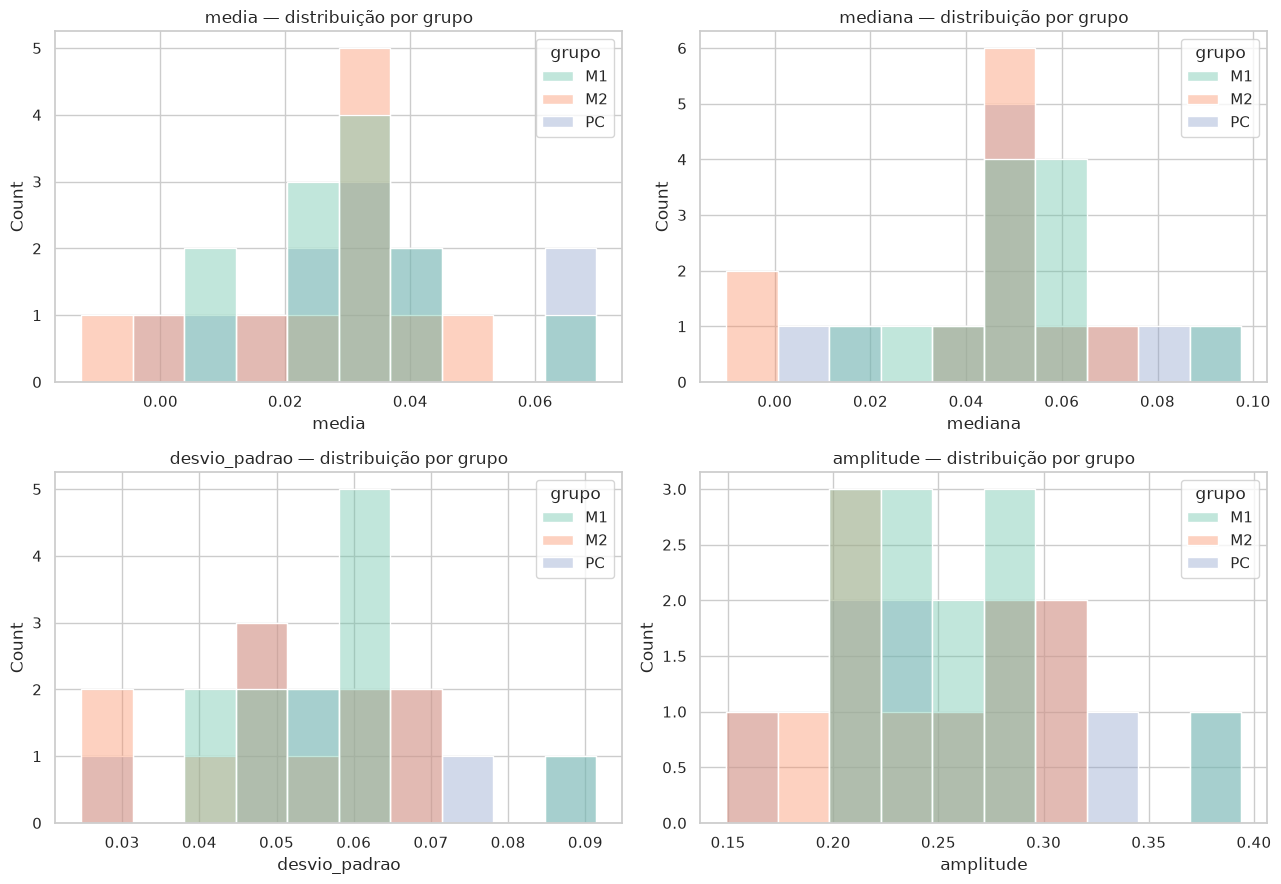

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, metrica in zip(axes.flatten(), metricas):
    sns.histplot(data=resumo, x=metrica, hue="grupo", bins=10,
        kde=False, alpha=0.4, ax=ax, palette="Set2")
    ax.set_title(f"{metrica} — distribuição por grupo")

plt.tight_layout()
plt.show()

Olhando o gráfico, vemos que os três grupos tem um movimento similar nas quatro métricas e se sobrepõem durante a maior parte das faixas. Esse comportamento é o esperado e condiz com as análises.

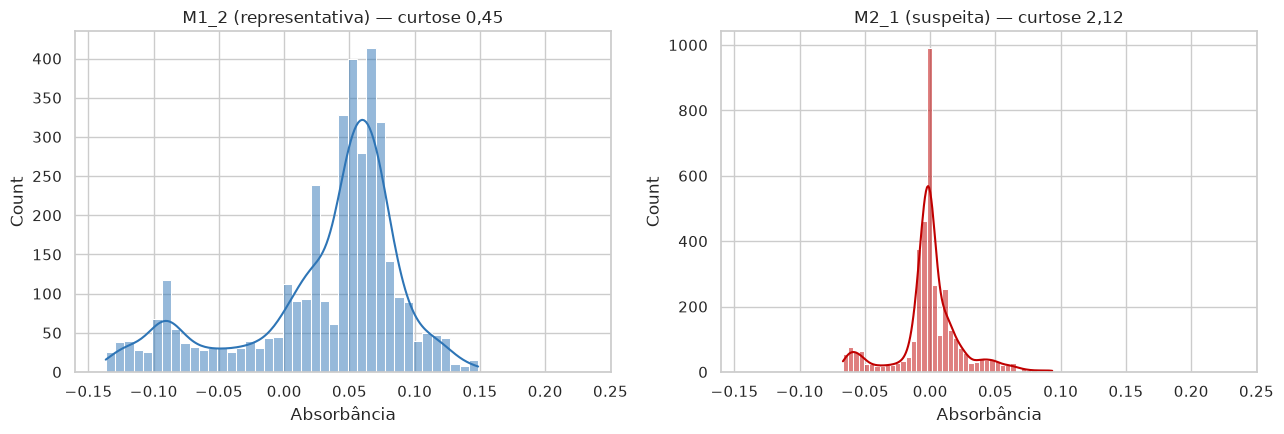

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(dataframe_limpo["M1_2"], bins=40, kde=True, ax=axes[0], color="#2E75B6")
axes[0].set_title("M1_2 (representativa) — curtose 0,45")

sns.histplot(dataframe_limpo["M2_1"], bins=40, kde=True, ax=axes[1], color="#C00000")
axes[1].set_title("M2_1 (suspeita) — curtose 2,12")

for ax in axes:
    ax.set_xlabel("Absorbância")
    ax.set_xlim(-0.16, 0.25)      # mesma escala nos dois — comparação justa

plt.tight_layout()
plt.show()

Aqui vemos mais um motivo de suspeita para M2_1. Sua curva mostra que uma quantidade muito elevada de valores estão muito próximas umas das outras e o gráfico fica mal distribuido.

---
# 🎲 Módulo 10 — Probabilidade

Vamos aplicar os conceitos fundamentais de probabilidade a eventos definidos sobre o próprio dataset.

### 10.1 Espaço amostral e eventos

Considere o experimento: **escolher uma amostra aleatoriamente**. O espaço amostral são as 35 amostras.

Vamos definir dois eventos:
- **A:** a amostra é saudável (`grupo == "PC"`)
- **B:** a amostra tem amplitude muito alta

In [116]:
total_amostras = len(resumo)

evento_A = resumo["grupo"] == "PC"
evento_B = resumo["amplitude"] > resumo["amplitude"].median()

P_A = evento_A.sum() / total_amostras
P_B = evento_B.sum() / total_amostras

print(f"P(A) = P(é saudável) = {P_A:.4f}")
print(f"P(B) = P(amplitude muito alta) = {P_B:.4f}")

P(A) = P(é saudável) = 0.3429
P(B) = P(amplitude muito alta) = 0.4857


### 10.2 Probabilidade conjunta P(A ∩ B)

In [117]:
P_A_e_B = (evento_A & evento_B).sum() / total_amostras
print(f"P(A ∩ B) = P(é saudável E tem amplitude alta) = {P_A_e_B:.4f}")

P(A ∩ B) = P(é saudável E tem amplitude alta) = 0.2000


### 10.3 Probabilidade condicional P(A | B)

"Dado que a amostra é saudável, qual a probabilidade de sua amplitude ser acima da mediana?"


In [119]:
P_A_dado_B = (evento_A & evento_B).sum() / evento_B.sum()
print(f"P(A | B) = {P_A_dado_B:.4f}")
print(f"Compare com P(A) = {P_A:.4f} (probabilidade sem a condição)")

P(A | B) = 0.4118
Compare com P(A) = 0.3429 (probabilidade sem a condição)


> 💡 Se `P(A | B)` for muito maior que `P(A)`, isso sugere que **células saudáveis têm maior chance de terem uma amplitude acima da mediana** — um indício de associação entre as variáveis, que investigaremos formalmente no Módulo 11.

### 10.4 Verificando independência

Dois eventos são independentes quando `P(A ∩ B) = P(A) × P(B)`.

In [120]:
produto_marginal = P_A * P_B

print(f"P(A) x P(B) = {produto_marginal:.4f}")
print(f"P(A ∩ B) observado = {P_A_e_B:.4f}")

if abs(produto_marginal - P_A_e_B) < 0.01:
    print("Os eventos parecem aproximadamente independentes.")
else:
    print("Os eventos NÃO parecem independentes — há indícios de associação.")

P(A) x P(B) = 0.1665
P(A ∩ B) observado = 0.2000
Os eventos NÃO parecem independentes — há indícios de associação.


---
# 🔗 Módulo 11 — Probabilidade Conjunta e Tabelas de Contingência

Vamos formalizar a investigação de associação entre variáveis categóricas usando tabelas de contingência.

### 11.1 Construindo a tabela de contingência

Vamos investigar a relação entre `CentralAir` (ar-condicionado central) e uma versão categorizada do ano de construção.

In [122]:
resumo["faixa_amplitude"] = pd.qcut(resumo["amplitude"], 3, labels=["Baixa", "Media", "Alta"])

tabela_contingencia = pd.crosstab(resumo["grupo"], resumo["faixa_amplitude"])
tabela_contingencia

faixa_amplitude,Baixa,Media,Alta
grupo,,,
M1,4,4,4
M2,5,2,4
PC,3,5,4


### 11.2 Convertendo em probabilidades

In [123]:
tabela_conjunta = pd.crosstab(resumo["grupo"], resumo["faixa_amplitude"], normalize="all")
print("Probabilidade conjunta P(Grupo ∩ Faixa):")
tabela_conjunta.round(3)

Probabilidade conjunta P(Grupo ∩ Faixa):


faixa_amplitude,Baixa,Media,Alta
grupo,,,
M1,0.114,0.114,0.114
M2,0.143,0.057,0.114
PC,0.086,0.143,0.114


In [124]:
tabela_condicional = pd.crosstab(resumo["grupo"], resumo["faixa_amplitude"], normalize="index")
print("Probabilidade condicional P(Faixa | Grupo):")
tabela_condicional.round(3)

Probabilidade condicional P(Faixa | Grupo):


faixa_amplitude,Baixa,Media,Alta
grupo,,,
M1,0.333,0.333,0.333
M2,0.455,0.182,0.364
PC,0.250,0.417,0.333


### 11.3 Probabilidades marginais

In [125]:
marginais_grupo = tabela_conjunta.sum(axis=1)
marginais_faixa = tabela_conjunta.sum(axis=0)

print("Probabilidade marginal por grupo:")
print(marginais_grupo.round(3))
print("\nProbabilidade marginal por faixa de amplitude:")
print(marginais_faixa.round(3))

Probabilidade marginal por grupo:
grupo
M1    0.343
M2    0.314
PC    0.343
dtype: float64

Probabilidade marginal por faixa de amplitude:
faixa_amplitude
Baixa    0.343
Media    0.314
Alta     0.343
dtype: float64


### 11.4 Visualizando a associação

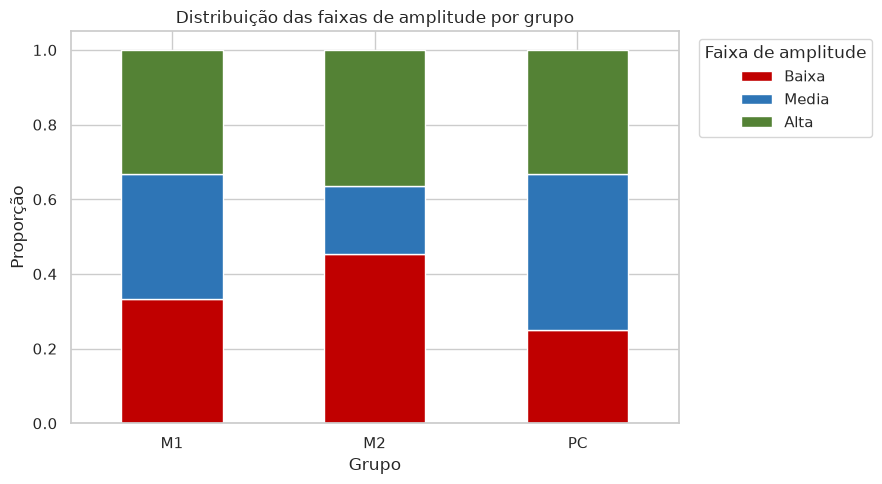

In [126]:
tabela_condicional.plot(kind="bar", stacked=True, figsize=(9, 5), color=["#C00000", "#2E75B6", "#548235"])
plt.title("Distribuição das faixas de amplitude por grupo")
plt.ylabel("Proporção")
plt.xlabel("Grupo")
plt.legend(title="Faixa de amplitude", bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> 💡 **Interpretação:** as três barras são extremamente similares umas às outras, com uma pequena exeção em M2, por um motivo já definido. Isso dá a entender que há pouquíssima ou nenhuma associação entre a amplitude de uma amostra e seu grupo, ela pode estar em qualquer um dos três numa mesma chance.

---
# 🔄 Módulo 12 — Correlação

Vamos investigar a correlação entre variáveis numéricas, usando os coeficientes de Pearson e Spearman.

### 12.1 Matriz de correlação (Pearson)

In [ ]:
variaveis_interesse = [
    "LotArea", "OverallQual", "OverallCond", "YearBuilt", "TotalBsmtSF",
    "GrLivArea", "FullBath", "GarageCars", "GarageArea"
]

matriz_corr = dataframe_limpo[variaveis_interesse].corr(method="pearson")
matriz_corr.round(2)

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", center=0, linewidths=0.5)
plt.title("Matriz de Correlação de Pearson")
plt.tight_layout()
plt.show()

### 12.2 Correlação de Spearman

Mais robusta a outliers e capaz de capturar relações monotônicas não necessariamente lineares.

In [ ]:
matriz_corr_spearman = dataframe_limpo[variaveis_interesse].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr_spearman, annot=True, cmap="coolwarm", fmt=".2f", center=0, linewidths=0.5)
plt.title("Matriz de Correlação de Spearman")
plt.tight_layout()
plt.show()

### 12.3 Identificando as correlações mais fortes

In [ ]:
corr_pares = matriz_corr.unstack().sort_values(ascending=False)
corr_pares = corr_pares[corr_pares < 1.0]  # remove a diagonal (correlação de uma variável com ela mesma)
corr_pares.drop_duplicates().head(10)

> ⚠️ **Correlação não implica causalidade.** `GarageCars` e `GarageArea` são fortemente correlacionadas — o que é esperado, já que garagens maiores comportam mais carros. Mas isso não significa que uma "causa" a outra: ambas refletem o mesmo atributo estrutural do imóvel (tamanho da garagem).

---
# 🖼️ Módulo 13 — Visualização de Dados

Vamos aplicar os principais tipos de gráficos apresentados na apostila para explorar visualmente o dataset.

### 13.1 Histograma

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(dataframe_limpo["GrLivArea"], bins=30, kde=True, color="#2E75B6")
plt.title("Histograma — Área construída (GrLivArea)")
plt.xlabel("Área construída (pés²)")
plt.show()

### 13.2 Boxplot (comparando grupos)

In [ ]:
plt.figure(figsize=(10, 6))
ordem = sorted(dataframe_limpo["OverallQual"].unique())
sns.boxplot(x="OverallQual", y="GrLivArea", data=dataframe_limpo, order=ordem, palette="Blues")
plt.title("Área construída por nota de qualidade geral (OverallQual)")
plt.xlabel("Qualidade geral (1-10)")
plt.ylabel("Área construída (pés²)")
plt.show()

### 13.3 Gráfico de dispersão (scatter plot)

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="GrLivArea", y="TotalBsmtSF", hue="OverallQual", data=dataframe_limpo, palette="viridis", alpha=0.7)
plt.title("Relação entre área construída e área do porão")
plt.xlabel("Área construída (pés²)")
plt.ylabel("Área do porão (pés²)")
plt.legend(title="Qualidade", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

### 13.4 Gráfico de barras

In [ ]:
plt.figure(figsize=(11, 5))
dataframe_limpo["Neighborhood_agrupado"].value_counts().plot(kind="bar", color="#548235")
plt.title("Número de imóveis por bairro (agrupado)")
plt.xlabel("Bairro")
plt.ylabel("Quantidade de imóveis")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

### 13.5 Gráfico de linhas (tendência ao longo do tempo)

In [ ]:
imoveis_por_ano = dataframe_limpo.groupby("YearBuilt").size()

plt.figure(figsize=(11, 5))
imoveis_por_ano.plot(kind="line", color="#C00000")
plt.title("Número de imóveis construídos por ano")
plt.xlabel("Ano de construção")
plt.ylabel("Quantidade de imóveis")
plt.show()

### 13.6 Heatmap

Já construído no Módulo 12 (matriz de correlação) — reforça como o heatmap é a ferramenta ideal para visualizar relações entre múltiplas variáveis numéricas de uma só vez.

### 13.7 Pairplot

In [ ]:
subset_pairplot = dataframe_limpo[["GrLivArea", "TotalBsmtSF", "OverallQual", "YearBuilt"]].sample(300, random_state=42)

sns.pairplot(subset_pairplot, diag_kind="kde", plot_kws={"alpha": 0.5, "color": "#2E75B6"})
plt.suptitle("Pairplot de variáveis numéricas selecionadas", y=1.02)
plt.show()

> 💡 Usamos uma amostra de 300 linhas para o pairplot por questões de desempenho — com datasets maiores, gerar o gráfico completo pode ser lento.

---
# 🛠️ Módulo 14 — Engenharia de Features

Vamos criar novas variáveis (features) a partir das colunas existentes, aplicando as técnicas apresentadas na apostila.

### 14.1 Discretização (binning)

Transformando `OverallQual` (nota numérica) em uma faixa categórica.

In [ ]:
dataframe_limpo["Faixa_Qualidade"] = pd.cut(
    dataframe_limpo["OverallQual"],
    bins=[0, 3, 6, 8, 10],
    labels=["Baixa", "Media", "Boa", "Excelente"]
)

dataframe_limpo[["OverallQual", "Faixa_Qualidade"]].drop_duplicates().sort_values("OverallQual")

### 14.2 Features temporais

Vamos criar variáveis derivadas de `YearBuilt` e `YrSold`.

In [ ]:
dataframe_limpo["Idade_Imovel"] = dataframe_limpo["YrSold"] - dataframe_limpo["YearBuilt"]
dataframe_limpo["Foi_Reformado"] = (dataframe_limpo["YearRemodAdd"] != dataframe_limpo["YearBuilt"]).astype(int)
dataframe_limpo["Anos_Desde_Reforma"] = dataframe_limpo["YrSold"] - dataframe_limpo["YearRemodAdd"]

dataframe_limpo[["YearBuilt", "YrSold", "Idade_Imovel", "Foi_Reformado", "Anos_Desde_Reforma"]].head()

### 14.3 Transformação logarítmica

Reduz a assimetria de variáveis com distribuição enviesada, como `LotArea` (vista no Módulo 8/9).

In [ ]:
dataframe_limpo["LotArea_log"] = np.log1p(dataframe_limpo["LotArea"])  # log1p evita problemas com valores zero

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(dataframe_limpo["LotArea"], bins=40, ax=axes[0], color="#C00000")
axes[0].set_title(f"LotArea original (assimetria = {dataframe_limpo['LotArea'].skew():.2f})")

sns.histplot(dataframe_limpo["LotArea_log"], bins=40, ax=axes[1], color="#2E75B6")
axes[1].set_title(f"LotArea (log) (assimetria = {dataframe_limpo['LotArea_log'].skew():.2f})")

plt.tight_layout()
plt.show()

### 14.4 Razões e combinações entre variáveis

In [ ]:
dataframe_limpo["Area_Total"] = dataframe_limpo["GrLivArea"] + dataframe_limpo["TotalBsmtSF"]
dataframe_limpo["Banheiros_Totais"] = dataframe_limpo["FullBath"] + 0.5 * dataframe_limpo["HalfBath"] + \
                                 dataframe_limpo["BsmtFullBath"] + 0.5 * dataframe_limpo["BsmtHalfBath"]
dataframe_limpo["Razao_Garagem_Area"] = dataframe_limpo["GarageArea"] / dataframe_limpo["Area_Total"].replace(0, np.nan)

dataframe_limpo[["GrLivArea", "TotalBsmtSF", "Area_Total", "Banheiros_Totais", "Razao_Garagem_Area"]].head()

### 14.5 Features estatísticas por grupo (agregação)

Criando a média de área construída por bairro como uma nova feature — útil para capturar o "padrão" de cada região.

In [ ]:
media_area_bairro = dataframe_limpo.groupby("Neighborhood")["GrLivArea"].transform("mean")
dataframe_limpo["Media_Area_Bairro"] = media_area_bairro

dataframe_limpo[["Neighborhood", "GrLivArea", "Media_Area_Bairro"]].head()

### 14.6 Feature específica do domínio

In [ ]:
# Proporção da área construída em relação à área do terreno — indica o "aproveitamento" do lote
dataframe_limpo["Aproveitamento_Lote"] = dataframe_limpo["Area_Total"] / dataframe_limpo["LotArea"]

dataframe_limpo[["Area_Total", "LotArea", "Aproveitamento_Lote"]].describe().round(2)

---
# ⚖️ Módulo 15 — Normalização e Padronização

Vamos comparar as duas técnicas de escalonamento apresentadas na apostila.

In [ ]:
colunas_para_escalar = ["GrLivArea", "LotArea", "Area_Total", "Idade_Imovel"]

dataframe_escala = dataframe_limpo[colunas_para_escalar].copy()
dataframe_escala.describe().round(2)

### 15.1 Min-Max Scaling

In [ ]:
min_max_scaler = MinMaxScaler()
dataframe_minmax = pd.DataFrame(
    min_max_scaler.fit_transform(dataframe_escala),
    columns=[f"{col}_minmax" for col in colunas_para_escalar]
)
dataframe_minmax.describe().round(3)

### 15.2 Standardization (StandardScaler)

In [ ]:
standard_scaler = StandardScaler()
dataframe_standard = pd.DataFrame(
    standard_scaler.fit_transform(dataframe_escala),
    columns=[f"{col}_standard" for col in colunas_para_escalar]
)
dataframe_standard.describe().round(3)

### 15.3 Comparação visual

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(dataframe_escala["GrLivArea"], bins=30, ax=axes[0], color="#8C8C8C")
axes[0].set_title("Original")

sns.histplot(dataframe_minmax["GrLivArea_minmax"], bins=30, ax=axes[1], color="#2E75B6")
axes[1].set_title("Min-Max Scaling (0 a 1)")

sns.histplot(dataframe_standard["GrLivArea_standard"], bins=30, ax=axes[2], color="#548235")
axes[2].set_title("Standardization (média 0, DP 1)")

plt.tight_layout()
plt.show()

> 💡 **Observação importante:** note que a **forma** da distribuição (a assimetria) permanece a mesma nas três versões — o escalonamento muda apenas a escala dos valores, não a distribuição relativa dos dados. Por isso, variáveis assimétricas costumam ser primeiro transformadas (ex.: log, Módulo 14) e só depois escalonadas.

### 15.4 Regra de ouro: fit apenas no treino

Em um projeto real, o `fit` do scaler deve ser feito **apenas com os dados de treinamento**, e o `transform` aplicado depois aos dados de validação/teste — evitando vazamento de dados (*data leakage*).

In [ ]:
from sklearn.model_selection import train_test_split

X_treino, X_teste = train_test_split(dataframe_escala, test_size=0.2, random_state=42)

scaler_correto = StandardScaler()
scaler_correto.fit(X_treino)  # ajusta apenas com dados de treino

X_treino_escalado = scaler_correto.transform(X_treino)
X_teste_escalado = scaler_correto.transform(X_teste)  # aplica os mesmos parâmetros ao teste

print("Scaler ajustado corretamente, sem vazamento de dados.")
print("Média do treino (usada no scaler):", X_treino["GrLivArea"].mean().round(2))

---
# 🎯 Módulo 16 — Seleção de Features

Vamos aplicar métodos de seleção de features para identificar as variáveis mais relevantes para prever a qualidade geral do imóvel (`OverallQual`), usada aqui como variável-alvo ilustrativa.

### 16.1 Preparando a base para seleção de features

In [ ]:
features_candidatas = [
    "LotArea", "YearBuilt", "TotalBsmtSF", "GrLivArea", "FullBath",
    "GarageCars", "GarageArea", "Idade_Imovel", "Area_Total", "Banheiros_Totais"
]

X = dataframe_limpo[features_candidatas].fillna(0)
y = dataframe_limpo["OverallQual"]

X.head()

### 16.2 Análise de correlação com a variável-alvo

In [ ]:
correlacao_com_alvo = X.assign(OverallQual=y).corr()["OverallQual"].drop("OverallQual").sort_values(ascending=False)
correlacao_com_alvo

### 16.3 Multicolinearidade entre features

Antes de selecionar, vamos identificar features redundantes entre si (alta correlação mútua).

In [ ]:
matriz_corr_features = X.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_corr_features, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlação entre as features candidatas (multicolinearidade)")
plt.tight_layout()
plt.show()

In [ ]:
# Identificando pares com correlação muito alta (> 0.8) — candidatos a redundância
pares_redundantes = matriz_corr_features.unstack()
pares_redundantes = pares_redundantes[(pares_redundantes.abs() > 0.8) & (pares_redundantes.abs() < 1.0)]
pares_redundantes.drop_duplicates()

> 💡 `Area_Total` foi construída a partir de `GrLivArea` e `TotalBsmtSF` (Módulo 14) — por isso apresenta alta correlação com ambas. Manter as três simultaneamente no modelo pode ser redundante.

### 16.4 SelectKBest

In [ ]:
selecionador = SelectKBest(score_func=f_regression, k=5)
selecionador.fit(X, y)

scores = pd.Series(selecionador.scores_, index=X.columns).sort_values(ascending=False)
print("Ranking de importância (F-score):")
print(scores)

features_selecionadas_kbest = X.columns[selecionador.get_support()]
print("\nFeatures selecionadas pelo SelectKBest:", list(features_selecionadas_kbest))

### 16.5 RFE (Recursive Feature Elimination)

In [ ]:
modelo_base = LinearRegression()
rfe = RFE(modelo_base, n_features_to_select=5)
rfe.fit(X, y)

features_selecionadas_rfe = X.columns[rfe.support_]
print("Features selecionadas pelo RFE:", list(features_selecionadas_rfe))

### 16.6 Importância de features via Random Forest

In [ ]:
modelo_rf = RandomForestRegressor(n_estimators=200, random_state=42)
modelo_rf.fit(X, y)

importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importancias.plot(kind="barh", color="#2E75B6")
plt.title("Importância das features (Random Forest)")
plt.xlabel("Importância")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

> 💡 **Conclusão do módulo:** os três métodos (correlação, SelectKBest e RFE/Random Forest) convergem, em geral, para features como `GrLivArea`, `Area_Total`, `TotalBsmtSF` e `GarageCars` como as mais relevantes — reforçando a ideia de que **mais features não significa necessariamente um modelo melhor**: o foco deve estar na relevância, não na quantidade.

---
# ⚠️ Módulo 17 — Dados Desbalanceados

Vamos utilizar a variável `Street` (tipo de acesso à via) como exemplo de classe fortemente desbalanceada, presente naturalmente neste dataset.

### 17.1 Identificando o desbalanceamento

In [ ]:
contagem_street = dataframe_limpo["Street"].value_counts()
proporcao_street = dataframe_limpo["Street"].value_counts(normalize=True) * 100

print(contagem_street)
print("\nProporção (%):")
print(proporcao_street.round(2))

In [ ]:
plt.figure(figsize=(6, 5))
contagem_street.plot(kind="bar", color=["#2E75B6", "#C00000"])
plt.title("Distribuição da variável Street (fortemente desbalanceada)")
plt.ylabel("Quantidade de imóveis")
plt.xticks(rotation=0)
plt.show()

> 💡 Apenas **6 imóveis** possuem acesso do tipo `Grvl` (cascalho), contra **1.453** do tipo `Pave` (pavimentado) — um desbalanceamento extremo (~99,6% vs. ~0,4%), similar ao exemplo de "1% falha / 99% normal" apresentado na apostila.

### 17.2 Por que a acurácia pode enganar

Se construíssemos um classificador ingênuo que **sempre prevê `"Pave"`**, qual seria sua acurácia?

In [ ]:
acuracia_ingenua = (dataframe_limpo["Street"] == "Pave").mean()
print(f"Acurácia de um modelo que sempre prevê 'Pave': {acuracia_ingenua:.4f} ({acuracia_ingenua*100:.2f}%)")
print("Apesar da acurácia altíssima, esse modelo NUNCA identificaria corretamente um imóvel com acesso 'Grvl'.")

### 17.3 Simulando undersampling e oversampling

Vamos ilustrar conceitualmente as duas técnicas, criando versões balanceadas do dataset (apenas com as colunas numéricas, para simplificar).

In [ ]:
colunas_exemplo = ["LotArea", "OverallQual", "GrLivArea", "Street"]
dataframe_desbalanceado = dataframe_limpo[colunas_exemplo].dropna()

classe_majoritaria = dataframe_desbalanceado[dataframe_desbalanceado["Street"] == "Pave"]
classe_minoritaria = dataframe_desbalanceado[dataframe_desbalanceado["Street"] == "Grvl"]

print(f"Classe majoritária (Pave): {len(classe_majoritaria)} registros")
print(f"Classe minoritária (Grvl): {len(classe_minoritaria)} registros")

In [ ]:
# Undersampling: reduz a classe majoritária ao tamanho da minoritária
undersample_majoritaria = classe_majoritaria.sample(n=len(classe_minoritaria), random_state=42)
dataframe_undersampled = pd.concat([undersample_majoritaria, classe_minoritaria])

print("Distribuição após undersampling:")
print(dataframe_undersampled["Street"].value_counts())

In [ ]:
# Oversampling: replica a classe minoritária até o tamanho da majoritária
oversample_minoritaria = classe_minoritaria.sample(n=len(classe_majoritaria), replace=True, random_state=42)
dataframe_oversampled = pd.concat([classe_majoritaria, oversample_minoritaria])

print("Distribuição após oversampling:")
print(dataframe_oversampled["Street"].value_counts())

### 17.4 SMOTE (conceitual)

O SMOTE gera exemplos **sintéticos** da classe minoritária, interpolando entre observações existentes (em vez de apenas duplicá-las, como no oversampling simples). Sua implementação prática requer a biblioteca `imbalanced-learn`:

```python
# pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=2)
X_resampled, y_resampled = smote.fit_resample(X, y)
```

> ⚠️ Com apenas 6 registros na classe minoritária, o SMOTE tem um número muito limitado de vizinhos para interpolar — nesse caso extremo, o undersampling ou a coleta de mais dados costumam ser alternativas mais adequadas.

### 17.5 Métricas apropriadas para dados desbalanceados

Em vez de depender apenas da acurácia, deve-se avaliar o modelo com métricas como **precisão**, **revocação (recall)**, **F1-score** e **AUC-ROC**, que consideram o desempenho especificamente na classe minoritária.

In [ ]:
from sklearn.metrics import classification_report

# Exemplo ilustrativo: um classificador ingênuo que sempre prevê a classe majoritária
y_real = dataframe_desbalanceado["Street"]
y_previsto_ingenuo = ["Pave"] * len(y_real)

print(classification_report(y_real, y_previsto_ingenuo, zero_division=0))

> 💡 **Observação final:** repare que, embora a acurácia global seja altíssima, a **precisão, revocação e F1-score da classe `Grvl`** são todas iguais a zero — o modelo ingênuo é completamente incapaz de identificar a classe minoritária. Este é exatamente o problema que as técnicas de balanceamento (undersampling, oversampling, SMOTE) e as métricas apropriadas buscam evidenciar e mitigar.

---
# ✅ Conclusão

Neste notebook, percorremos na prática os Módulos 2 a 17 da apostila *Engenharia e Preparação de Dados*, aplicando cada técnica ao dataset real de imóveis (`dados_imoveis.csv`):

- Carregamos e exploramos os dados brutos (Módulo 2);
- Diagnosticamos problemas de qualidade (Módulo 3) e os corrigimos (Módulo 4);
- Codificamos variáveis categóricas (Módulo 5) e analisamos variáveis numéricas (Módulo 6);
- Detectamos outliers (Módulo 7) e aprofundamos a análise estatística (Módulo 8);
- Visualizamos distribuições (Módulo 9) e aplicamos conceitos de probabilidade (Módulos 10 e 11);
- Investigamos correlações (Módulo 12) e construímos visualizações diversas (Módulo 13);
- Criamos novas features (Módulo 14) e as normalizamos (Módulo 15);
- Selecionamos as features mais relevantes (Módulo 16) e discutimos o desafio de classes desbalanceadas (Módulo 17).

> 🎯 **Próximos passos sugeridos:** aplicar os Módulos 21 e 22 da apostila (Separação entre Treinamento/Validação/Teste e Pipeline Completo de Pré-processamento) para consolidar tudo o que foi feito aqui em um pipeline único, reprodutível e pronto para alimentar um modelo de Machine Learning.
